# 제주 특산물 가격 예측 - DNN + Embedding

| 항목 | 내용 |
|------|------|
| **버전** | v1.1.0 |
| **날짜** | 2026-03-12 |
| **모델** | Keras DNN + Embedding Layer |
| **전처리** | v1.0.1 동일 |
| **출력** | results/submission_v1.1.0.csv |

## v1.1.0 변경 내용
| 항목 | v1.0.1 | v1.1.0 |
|------|--------|--------|
| 범주형 인코딩 | get_dummies (고차원 sparse) | **Embedding 레이어** (저차원 dense) |
| 모델 입력 | 단일 벡터 | **Multi-input** (수치형 + item/corp/loc 각각) |
| 임베딩 차원 | — | `min(50, (n+1)//2)` 자동 설정 |
| 기대 효과 | — | 범주 간 유사도 학습, 파라미터 효율 향상 |

---
## 1. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, datetime, random, os, platform
warnings.filterwarnings('ignore')

import holidays

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 2024
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {bool(tf.config.list_physical_devices("GPU"))}')

TensorFlow: 2.20.0
GPU: False


---
## 2. 데이터 로드

In [ ]:
DATA_PATH = '../data/'
train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')
print(f'train: {train.shape}, test: {test.shape}')
train.head(3)

train: (59397, 7), test: (1092, 5)


,ID,timestamp,item,corporation,location,supply(kg),price(원/kg)
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0


---
## 3. 전처리 (v1.0.1 동일)

In [3]:
def pre_all(train, test):
    train['timestamp'] = pd.to_datetime(train['timestamp'])
    test['timestamp']  = pd.to_datetime(test['timestamp'])
    df = pd.concat([train, test]).reset_index(drop=True)
    df.rename(columns={'supply(kg)': 'supply', 'price(원/kg)': 'price'}, inplace=True)

    df['year']     = df['timestamp'].dt.year
    df['month']    = df['timestamp'].dt.month
    df['day']      = df['timestamp'].dt.day
    df['week_day'] = df['timestamp'].dt.weekday

    le = LabelEncoder()
    df['year_month'] = df['timestamp'].map(lambda x: f'{x.year}-{x.month}')
    df['year_month'] = le.fit_transform(df['year_month'])

    df['week'] = df['timestamp'].map(
        lambda x: datetime.datetime(x.year, x.month, x.day).isocalendar()[1]
    )
    week_offsets = {2019: 0, 2020: 52, 2021: 52+53, 2022: 52+53+53, 2023: 52+53+53+52}
    df['week_num'] = df.apply(lambda r: int(r['week']) + week_offsets.get(r['year'], 0), axis=1)
    df.loc[df['timestamp'] == '2019-12-30', 'week_num'] = 52
    df.loc[df['timestamp'] == '2019-12-31', 'week_num'] = 52

    kr_holi = holidays.KR()
    df['holiday'] = df['timestamp'].map(lambda x: 1 if x in kr_holi else 0)

    train_out = df[~df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    test_out  = df[ df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    print(f'전처리 완료 — train: {train_out.shape}, test: {test_out.shape}')
    return train_out, test_out

train_pre, test_pre = pre_all(train, test)

전처리 완료 — train: (59397, 15), test: (1092, 15)


---
## 4. 이상치 처리 + 타겟 변환

In [4]:
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    idx = train_pre[(train_pre['item'] == item) & (train_pre['price'] > thr)].index
    if len(idx):
        mean_p = train_pre[(train_pre['item'] == item) & (train_pre['price'] != 0)]['price'].mean()
        train_pre.loc[idx, 'price'] = mean_p
        print(f'{item}: {len(idx)}개 이상치 → 평균({mean_p:.0f})')

train_pre['price_transformed'] = np.where(
    train_pre['item'] == 'TG',
    np.sqrt(train_pre['price']),
    np.log1p(train_pre['price'])
)

# TG 공휴일 보정
tg_mask = (train_pre['item'] == 'TG') & (train_pre['holiday'] == 1) & (train_pre['price'] != 0)
active_holi = list(train_pre[tg_mask].groupby('timestamp').count().reset_index()['timestamp'])
fix_idx = train_pre[train_pre['timestamp'].isin(active_holi)].index
train_pre.loc[fix_idx, 'holiday'] = 0
print(f'TG 공휴일 보정: {len(fix_idx)}개')

TG: 1개 이상치 → 평균(4145)
RD: 1개 이상치 → 평균(564)
BC: 1개 이상치 → 평균(2757)
CB: 7개 이상치 → 평균(715)
TG 공휴일 보정: 1521개


---
## 5. 임베딩 인코더 + 수치형 피처 준비

> **핵심 변경**: item / corporation / location을 정수 인덱스로 변환 후 Embedding 레이어로 처리

In [5]:
NUM_FEAT_COLS = ['year', 'month', 'day', 'week_day', 'year_month', 'week_num', 'holiday']
CAT_COLS      = ['item', 'corporation', 'location']

# train + test 합쳐 fit → unseen 카테고리 방지
item_le = LabelEncoder().fit(
    pd.concat([train_pre['item'], test_pre['item']])
)
corp_le = LabelEncoder().fit(
    pd.concat([train_pre['corporation'], test_pre['corporation']])
)
loc_le = LabelEncoder().fit(
    pd.concat([train_pre['location'], test_pre['location']])
)

N_ITEMS = len(item_le.classes_)
N_CORPS = len(corp_le.classes_)
N_LOCS  = len(loc_le.classes_)

# 임베딩 차원: min(50, (n+1)//2)
EMB_DIM_ITEM = min(50, max(2, (N_ITEMS + 1) // 2))
EMB_DIM_CORP = min(50, max(2, (N_CORPS + 1) // 2))
EMB_DIM_LOC  = min(50, max(2, (N_LOCS  + 1) // 2))

print(f'item: {N_ITEMS}개  emb_dim={EMB_DIM_ITEM}')
print(f'corp: {N_CORPS}개  emb_dim={EMB_DIM_CORP}')
print(f'loc : {N_LOCS}개   emb_dim={EMB_DIM_LOC}')
print(f'수치형 피처: {len(NUM_FEAT_COLS)}개')

item: 5개  emb_dim=3
corp: 6개  emb_dim=3
loc : 2개   emb_dim=2
수치형 피처: 7개


In [6]:
def prepare_inputs(df, scaler=None):
    """[X_num, X_item, X_corp, X_loc] 형태로 반환"""
    X_num = df[NUM_FEAT_COLS].values.astype(np.float32)
    if scaler is not None:
        X_num = scaler.transform(X_num)
    X_item = item_le.transform(df['item']).reshape(-1, 1).astype(np.int32)
    X_corp = corp_le.transform(df['corporation']).reshape(-1, 1).astype(np.int32)
    X_loc  = loc_le.transform(df['location']).reshape(-1, 1).astype(np.int32)
    return [X_num, X_item, X_corp, X_loc]


# 시간순 8:2 분리
tr_sorted = train_pre.sort_values('year_month').reset_index(drop=True)
sp        = int(len(tr_sorted) * 0.8)
train_df  = tr_sorted.iloc[:sp]
val_df    = tr_sorted.iloc[sp:]

num_scaler = StandardScaler()
num_scaler.fit(train_df[NUM_FEAT_COLS].values)

inputs_tr   = prepare_inputs(train_df,  num_scaler)
inputs_vl   = prepare_inputs(val_df,    num_scaler)
inputs_test = prepare_inputs(test_pre,  num_scaler)

y_tr       = train_df['price_transformed'].values.astype(np.float32)
y_vl       = val_df['price_transformed'].values.astype(np.float32)
y_vl_orig  = val_df['price'].values
is_tg_vl   = (val_df['item'] == 'TG').values
test_is_tg = (test_pre['item'] == 'TG').values

print(f'학습: {inputs_tr[0].shape[0]:,}행, 검증: {inputs_vl[0].shape[0]:,}행')

학습: 47,517행, 검증: 11,880행


---
## 6. Embedding DNN 모델 설계

```
inp_num(7)  ─────────────────────────────────────────────┐
inp_item(1) → Embedding(N_ITEMS, dim) → Flatten(dim) ───┤
inp_corp(1) → Embedding(N_CORPS, dim) → Flatten(dim) ───┼→ Concat → Dense(256)→BN→ReLU→Drop
inp_loc (1) → Embedding(N_LOCS,  dim) → Flatten(dim) ───┘          → Dense(128)→BN→ReLU→Drop
                                                                     → Dense(64) →BN→ReLU→Drop
                                                                     → Dense(32) →BN→ReLU
                                                                     → Dense(1)
```

In [7]:
def build_dnn_emb(n_num, n_items, n_corps, n_locs,
                   emb_dim_item, emb_dim_corp, emb_dim_loc, lr=1e-3):
    l2 = regularizers.l2(1e-4)

    inp_num  = keras.Input(shape=(n_num,), name='numeric')
    inp_item = keras.Input(shape=(1,),     name='item')
    inp_corp = keras.Input(shape=(1,),     name='corp')
    inp_loc  = keras.Input(shape=(1,),     name='loc')

    e_item = layers.Flatten()(layers.Embedding(n_items, emb_dim_item, name='emb_item')(inp_item))
    e_corp = layers.Flatten()(layers.Embedding(n_corps, emb_dim_corp, name='emb_corp')(inp_corp))
    e_loc  = layers.Flatten()(layers.Embedding(n_locs,  emb_dim_loc,  name='emb_loc')(inp_loc))

    x = layers.Concatenate()([inp_num, e_item, e_corp, e_loc])

    for units, drop in [(256, 0.3), (128, 0.2), (64, 0.1), (32, 0.0)]:
        x = layers.Dense(units, kernel_regularizer=l2)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        if drop > 0:
            x = layers.Dropout(drop)(x)

    out = layers.Dense(1)(x)

    model = keras.Model(
        inputs=[inp_num, inp_item, inp_corp, inp_loc],
        outputs=out,
        name='jeju_dnn_emb_v1.1'
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mae',
        metrics=['mse']
    )
    return model


model = build_dnn_emb(
    len(NUM_FEAT_COLS), N_ITEMS, N_CORPS, N_LOCS,
    EMB_DIM_ITEM, EMB_DIM_CORP, EMB_DIM_LOC
)
model.summary()

Model: "jeju_dnn_emb_v1.1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ item (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ corp (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loc (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_item            │ (None, 1, 3)      │         15 │ item[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_corp            │ (None, 1, 3)      │         18 │ corp[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_loc (Embedding) │ (None, 1, 2)      │          4 │ loc[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3)         │          0 │ emb_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ emb_corp[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_loc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 15)        │          0 │ numeric[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      4,096 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0] 

 Total params: 49,318 (192.65 KB)

 Trainable params: 48,358 (188.90 KB)

 Non-trainable params: 960 (3.75 KB)

---
## 7. 학습

In [8]:
os.makedirs('./models',  exist_ok=True)
os.makedirs('./results', exist_ok=True)

MODEL_PATH = './models/jeju_dnn_emb_v1.1.0.keras'

cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=20,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=8, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_loss',
                              save_best_only=True, verbose=0)
]

history = model.fit(
    inputs_tr, y_tr,
    validation_data=(inputs_vl, y_vl),
    epochs=200,
    batch_size=512,
    callbacks=cb_list,
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss'])
print(f'\nBest Epoch: {best_epoch}, Val MAE: {min(history.history["val_loss"]):.4f}')

Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 12.7119 - mse: 734.4775 - val_loss: 14.6889 - val_mse: 924.0921 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 10.4562 - mse: 497.3126 - val_loss: 11.7806 - val_mse: 586.4719 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5398 - mse: 356.9286 - val_loss: 9.2322 - val_mse: 357.3387 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8473 - mse: 241.3397 - val_loss: 7.7002 - val_mse: 258.1759 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.4292 - mse: 156.0189 - val_loss: 6.1128 - val_mse: 172.7932 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4346 - mse: 115.2718 - val_loss: 5.5670 - val_mse: 146.9352 - learning_rate: 0.0010
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9720 - mse: 108.3836 - val_loss: 5.1781 - val_mse: 137.516

---
## 8. 학습 곡선

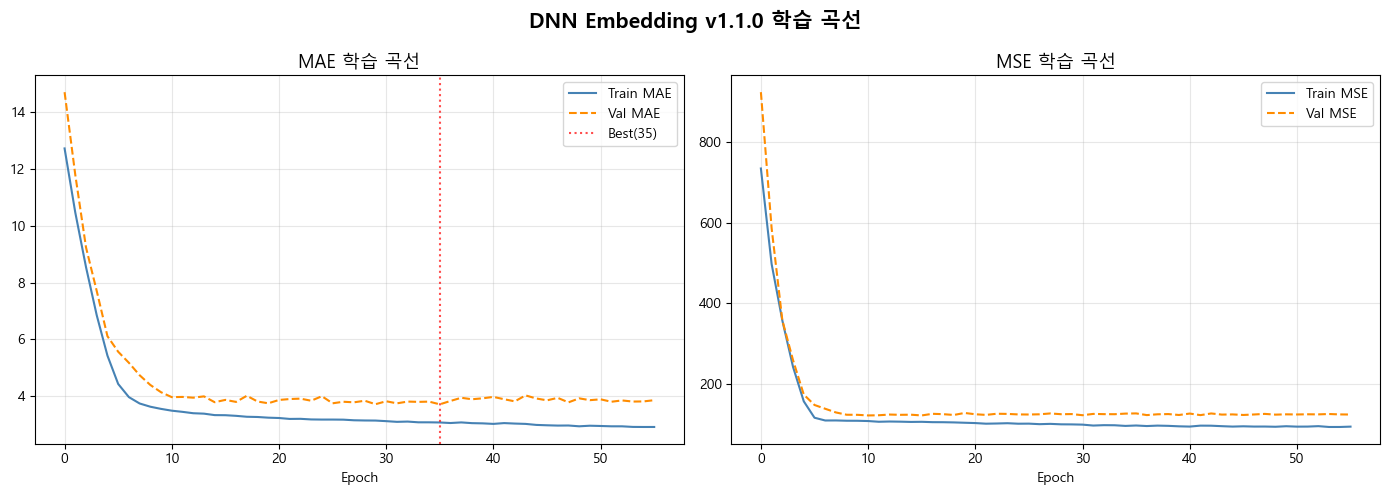

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train MAE', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val MAE',   color='darkorange', ls='--')
axes[0].axvline(best_epoch, color='red', ls=':', alpha=0.7, label=f'Best({best_epoch})')
axes[0].set_title('MAE 학습 곡선', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mse'],     label='Train MSE', color='steelblue')
axes[1].plot(history.history['val_mse'], label='Val MSE',   color='darkorange', ls='--')
axes[1].set_title('MSE 학습 곡선', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('DNN Embedding v1.1.0 학습 곡선', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/training_curve_v1.1.0.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. 모델 평가

In [10]:
y_pred_trf = model.predict(inputs_vl, verbose=0).flatten()

y_pred_orig = np.where(
    is_tg_vl,
    np.power(np.clip(y_pred_trf, 0, None), 2),
    np.expm1(y_pred_trf)
)
y_pred_orig = np.clip(y_pred_orig, 0, None)

mae  = mean_absolute_error(y_vl_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_vl_orig, y_pred_orig))
r2   = r2_score(y_vl_orig, y_pred_orig)
mape = np.mean(np.abs((y_vl_orig - y_pred_orig) / (y_vl_orig + 1e-8))) * 100

print('=' * 50)
print('  DNN Embedding v1.1.0 검증 성능')
print('=' * 50)
print(f'  MAE  : {mae:>10,.2f} 원/kg')
print(f'  RMSE : {rmse:>10,.2f} 원/kg')
print(f'  R²   : {r2:>10.4f}')
print(f'  MAPE : {mape:>10.2f} %')
print('=' * 50)

  DNN Embedding v1.1.0 검증 성능
  MAE  :     536.88 원/kg
  RMSE :   1,189.48 원/kg
  R²   :     0.7216
  MAPE : 1313639133686.72 %


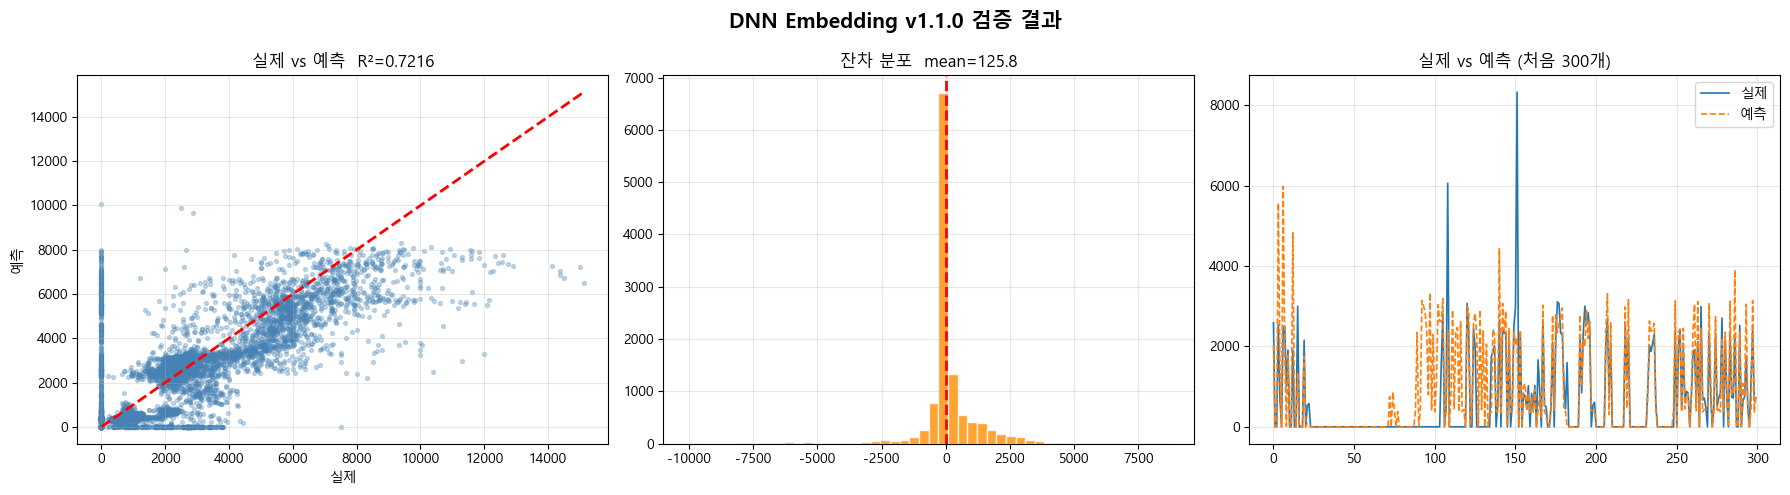

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

max_v = max(y_vl_orig.max(), y_pred_orig.max())
axes[0].scatter(y_vl_orig, y_pred_orig, alpha=0.3, s=8, color='steelblue')
axes[0].plot([0, max_v], [0, max_v], 'r--', lw=2)
axes[0].set_title(f'실제 vs 예측  R²={r2:.4f}', fontsize=12)
axes[0].set_xlabel('실제'); axes[0].set_ylabel('예측'); axes[0].grid(alpha=0.3)

res = y_vl_orig - y_pred_orig
axes[1].hist(res, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=2, ls='--')
axes[1].set_title(f'잔차 분포  mean={res.mean():.1f}', fontsize=12); axes[1].grid(alpha=0.3)

n = min(300, len(y_vl_orig))
axes[2].plot(y_vl_orig[:n],   label='실제', lw=1.2)
axes[2].plot(y_pred_orig[:n], label='예측', lw=1.2, ls='--')
axes[2].set_title(f'실제 vs 예측 (처음 {n}개)', fontsize=12)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('DNN Embedding v1.1.0 검증 결과', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/eval_plots_v1.1.0.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 테스트 예측 + 후처리 + 제출

In [12]:
test_pred_trf = model.predict(inputs_test, verbose=0).flatten()

test_pred_orig = np.where(
    test_is_tg,
    np.power(np.clip(test_pred_trf, 0, None), 2),
    np.expm1(test_pred_trf)
)
test_pred_orig = np.clip(test_pred_orig, 0, None)

# 후처리
result_df = test_pre[['ID', 'item']].copy()
result_df['answer'] = test_pred_orig

min_thresholds = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for item, thr in min_thresholds.items():
    mask = (result_df['item'] == item) & (result_df['answer'] < thr)
    result_df.loc[mask, 'answer'] = 0.0
    if mask.sum() > 0:
        print(f'{item}: {mask.sum()}개 → 0 처리')

print('\n예측 통계:')
print(result_df.groupby('item')['answer'].agg(['mean','min','max']).round(1))

result = sub[['ID']].merge(result_df[['ID', 'answer']], on='ID', how='left')
result['answer'] = result['answer'].fillna(0.0)

SUBMISSION_PATH = './results/submission_v1.1.0.csv'
result.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8-sig')
print(f'\n저장: {SUBMISSION_PATH}')
result.head(10)

TG: 40개 → 0 처리
CB: 44개 → 0 처리
RD: 56개 → 0 처리
CR: 106개 → 0 처리
BC: 84개 → 0 처리

예측 통계:
             mean  min          max
item                               
BC     820.799988  0.0  2266.899902
CB     260.299988  0.0   433.100006
CR     236.199997  0.0   628.700012
RD     235.600006  0.0   368.500000
TG    2614.600098  0.0  3459.399902

저장: ./results/submission_v1.1.0.csv


,ID,answer
0,TG_A_J_20230304,2549.481689
1,TG_A_J_20230305,0.000000
2,TG_A_J_20230306,2822.758545
3,TG_A_J_20230307,2823.215332
4,TG_A_J_20230308,2809.549072
5,TG_A_J_20230309,2795.841553
6,TG_A_J_20230310,2805.499023
7,TG_A_J_20230311,2723.911865
8,TG_A_J_20230312,0.000000
9,TG_A_J_20230313,2927.280762


---
## 11. 결과 요약

In [13]:
print('=' * 60)
print('  DNN Embedding v1.1.0 최종 결과')
print('=' * 60)
print(f'  수치형 피처  : {len(NUM_FEAT_COLS)}개')
print(f'  Embedding    : item({EMB_DIM_ITEM}) + corp({EMB_DIM_CORP}) + loc({EMB_DIM_LOC})')
print(f'  학습 데이터  : {inputs_tr[0].shape[0]:,}행')
print(f'  검증 데이터  : {inputs_vl[0].shape[0]:,}행')
print(f'  Best Epoch   : {best_epoch}')
print()
print('  [검증 성능]')
print(f'  MAE  = {mae:>10,.2f} 원/kg')
print(f'  RMSE = {rmse:>10,.2f} 원/kg')
print(f'  R²   = {r2:>10.4f}')
print(f'  MAPE = {mape:>10.2f} %')
print()
print(f'  제출 파일: {SUBMISSION_PATH}')
print(f'  모델 파일: {MODEL_PATH}')
print('=' * 60)

  DNN Embedding v1.1.0 최종 결과
  수치형 피처  : 7개
  Embedding    : item(3) + corp(3) + loc(2)
  학습 데이터  : 47,517행
  검증 데이터  : 11,880행
  Best Epoch   : 35

  [검증 성능]
  MAE  =     536.88 원/kg
  RMSE =   1,189.48 원/kg
  R²   =     0.7216
  MAPE = 1313639133686.72 %

  제출 파일: ./results/submission_v1.1.0.csv
  모델 파일: ./models/jeju_dnn_emb_v1.1.0.keras


### 다음 버전

| 버전 | 개선 내용 |
|------|----------|
| **v1.2.0** | Residual Connection 추가 |